In [4]:
import os
from PIL import Image
import plotly.express as px
import colorgram
import numpy as np
import pandas as pd
from scipy.stats import gaussian_kde

In [5]:
img_folder = os.path.join("../../","Dataset/","ZAPATOS")
img_folder

'../../Dataset/ZAPATOS'

In [7]:
imgs = os.listdir(img_folder)
len(imgs)

2370

In [8]:
imgs_sizes = []
for i in imgs:
    img = Image.open(img_folder+"/"+ i)
    imgs_sizes.append(img.size)


In [9]:
imgs_desc_dict = {}

for i, j in zip(imgs, imgs_sizes):
    imgs_desc_dict.update({i: j})

In [10]:
imgs_desc_dict

{'Jordan_11_Retro_Rare_Air_4of.jpg': (800, 571),
 'Nike_Zoom_Mercurial_Vapor_16_Elite_FG_Vini_Jr_Vini_Fly.jpg': (800, 571),
 'Gucci_Ace_Black_GG_990.jpg': (800, 571),
 'Nike_Clogposite_Light_Orewood_Brown.jpg': (800, 571),
 'Reebok_Classic_Leather_Outdoor_Vibes_Alabaster_Black_v1y.jpg': (800, 571),
 'Nike_Air_Max_95_QS_Big_Bubble_Baroque_Brown_Leather_t6h.jpg': (800, 571),
 'Jordan_1_Retro_High_OG_SP_Union_LA_Bephies_Beauty_Supply_Summer_of_96_b04.jpg': (800,
  571),
 'Nike_Air_Zoom_Maxfly_Hyper_Pink_Laser_Orange_qex.jpg': (800, 571),
 'adidas_Yeezy_500_Stone_Salt_5zf.jpg': (800, 571),
 'adidas_Taekwondo_Mei_Ballet_Clear_Sky_White_Womens.jpg': (800, 571),
 'Jordan_1_Retro_High_OG_University_Blue_zbr.jpg': (800, 571),
 'Nike_ReactX_Rejuven8_Green_Strike_atl.jpg': (800, 571),
 'Nike_Air_Foamposite_One_Triple_White_4z4.jpg': (800, 571),
 'Nike_Mercurial_Vapor_16_Elite_AG_Prism_Pack_bn1.jpg': (800, 571),
 'Timberland_Field_Boot_Lace_Up_Waterproof_Black_lb1.jpg': (800, 571),
 'adidas_Handba

In [13]:
df = pd.DataFrame(imgs_desc_dict).T
df.rename(columns={0: 'Width', 1: 'Height'}, inplace=True)

df

,Width,Height
Jordan_11_Retro_Rare_Air_4of.jpg,800,571
Nike_Zoom_Mercurial_Vapor_16_Elite_FG_Vini_Jr_Vini_Fly.jpg,800,571
Gucci_Ace_Black_GG_990.jpg,800,571
Nike_Clogposite_Light_Orewood_Brown.jpg,800,571
Reebok_Classic_Leather_Outdoor_Vibes_Alabaster_Black_v1y.jpg,800,571
...,...,...
adidas_Samba_Spikeless_Golf_Barstool_White_Collegiate_Green.jpg,800,571
Bravest_Studios_Foot_Clog_Green_llu.jpg,800,571
adidas_Copa_Pure_3_Elite_FG_Lucid_Lemon_Pack_jlv.jpg,800,571
UGG_Classic_Ultra_Mini_Boot_Chestnut_Womens.jpg,800,571


In [14]:
imgs_color_profile = []

for i in imgs:
    img = Image.open(img_folder+"/"+ i)
    colors = colorgram.extract(img, 3)
    
    for j in colors:
        r = j.rgb.r
        g = j.rgb.g
        b = j.rgb.b

    imgs_color_profile.append([r,g,b])

In [15]:
df['icp'] = imgs_color_profile
df['icp_u'] = [np.mean(profile) for profile in imgs_color_profile]

In [16]:
df

,Width,Height,icp,icp_u
Jordan_11_Retro_Rare_Air_4of.jpg,800,571,"[46, 53, 96]",65.000000
Nike_Zoom_Mercurial_Vapor_16_Elite_FG_Vini_Jr_Vini_Fly.jpg,800,571,"[43, 47, 49]",46.333333
Gucci_Ace_Black_GG_990.jpg,800,571,"[76, 75, 74]",75.000000
Nike_Clogposite_Light_Orewood_Brown.jpg,800,571,"[207, 192, 172]",190.333333
Reebok_Classic_Leather_Outdoor_Vibes_Alabaster_Black_v1y.jpg,800,571,"[178, 173, 156]",169.000000
...,...,...,...,...
adidas_Samba_Spikeless_Golf_Barstool_White_Collegiate_Green.jpg,800,571,"[153, 168, 157]",159.333333
Bravest_Studios_Foot_Clog_Green_llu.jpg,800,571,"[105, 176, 136]",139.000000
adidas_Copa_Pure_3_Elite_FG_Lucid_Lemon_Pack_jlv.jpg,800,571,"[36, 37, 40]",37.666667
UGG_Classic_Ultra_Mini_Boot_Chestnut_Womens.jpg,800,571,"[81, 46, 25]",50.666667


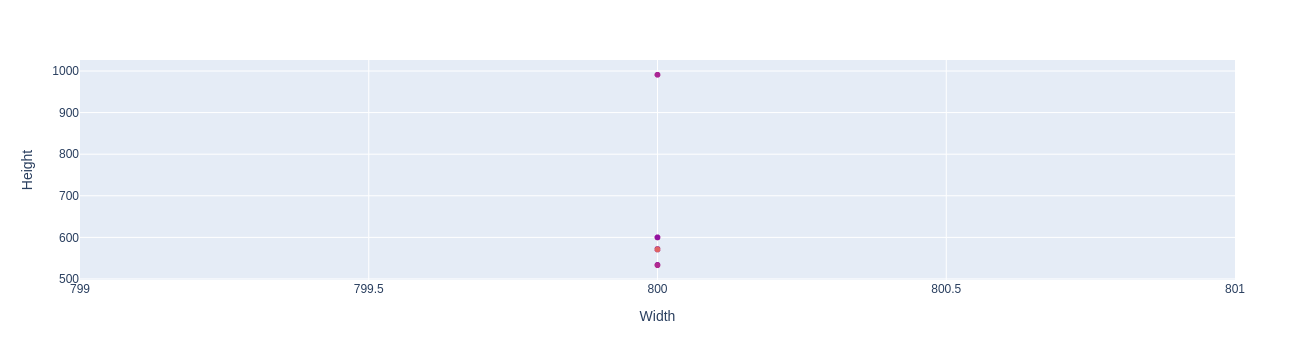

In [17]:
# Plotly Shape Profile 
fig = px.scatter(
    df, 
    x="Width", 
    y="Height", 
    hover_name=df.index, 
    color="icp_u"
    )
fig.update_layout(coloraxis_showscale=False)
fig.show()

In [19]:
df["Width"].value_counts(), df["Height"].value_counts()

(Width
 800    2370
 Name: count, dtype: int64,
 Height
 571    2335
 572      14
 600       9
 991       7
 533       3
 534       2
 Name: count, dtype: int64)

In [20]:
df[['Red','Green','Blue']] = pd.DataFrame(df['icp'].tolist(), index=df.index)
df.head()

,Width,Height,icp,icp_u,Red,Green,Blue
Jordan_11_Retro_Rare_Air_4of.jpg,800,571,"[46, 53, 96]",65.000000,46,53,96
Nike_Zoom_Mercurial_Vapor_16_Elite_FG_Vini_Jr_Vini_Fly.jpg,800,571,"[43, 47, 49]",46.333333,43,47,49
Gucci_Ace_Black_GG_990.jpg,800,571,"[76, 75, 74]",75.000000,76,75,74
Nike_Clogposite_Light_Orewood_Brown.jpg,800,571,"[207, 192, 172]",190.333333,207,192,172
Reebok_Classic_Leather_Outdoor_Vibes_Alabaster_Black_v1y.jpg,800,571,"[178, 173, 156]",169.000000,178,173,156


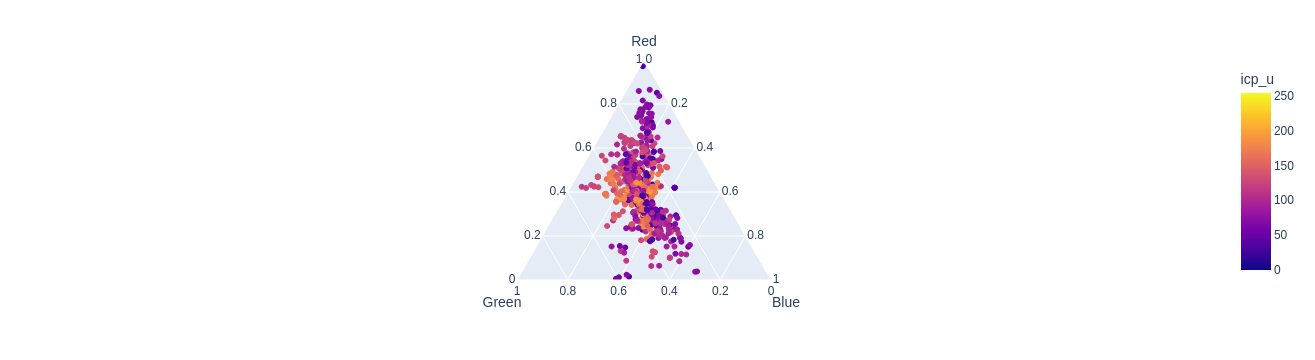

In [21]:
# Plotly Color Profile
fig = px.scatter_ternary(df,a="Red", b="Green", c="Blue",color="icp_u", hover_name=df.index)
fig.show()

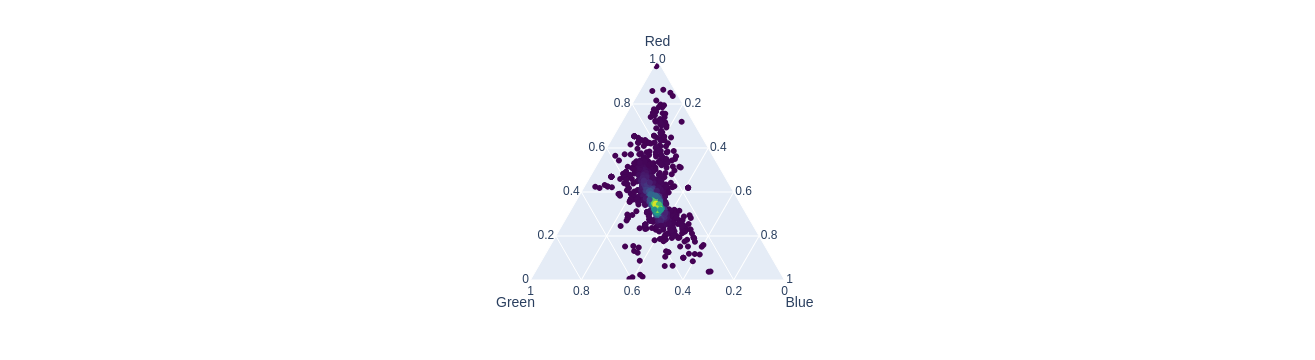

In [22]:
sum_cols = df["Red"] + df["Green"] + df["Blue"]
mask = sum_cols > 0
df_clean = df[mask].copy()

a = df_clean["Red"] / sum_cols[mask]
b = df_clean["Green"] / sum_cols[mask]
c = df_clean["Blue"] / sum_cols[mask]

x = b + c/2
y = (np.sqrt(3)/2) * c

valid_mask = np.isfinite(x) & np.isfinite(y)
x = x[valid_mask]
y = y[valid_mask]
df_clean = df_clean[valid_mask]

xy = np.vstack([x, y])
kde = gaussian_kde(xy)(xy)
df_clean["density"] = kde

fig = px.scatter_ternary(
    df_clean,
    a="Red",
    b="Green",
    c="Blue",
    color="density",
    hover_name=df_clean.index,
    color_continuous_scale="Viridis"
)

fig.update_layout(coloraxis_showscale=False)

fig.show()

fig.write_html("ternary_density.html")